In [15]:
import pandas as pd
import numpy as np
import shap

baseline_shap = pd.read_csv(
    "./results/lr_shap_baseline_feature_importance.csv"
)

baseline_shap

,feature,mean_abs_shap
0,ca,0.163206
1,thal,0.088952
2,sex,0.074529
3,cp,0.054862
4,exang,0.046295
5,slope,0.042123
6,thalach,0.036870
7,trestbps,0.023443
8,restecg,0.023003
9,oldpeak,0.014588


In [16]:
df = pd.read_csv("./dataset/heart_clean.csv")

x = df.drop("target", axis=1)
y = df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

x_test_np = x_test.to_numpy()


In [17]:
def compute_shap_importance(model, scaler, X_train_np, X_test_np, feature_names):
    
    X_train_scaled = scaler.transform(X_train_np)
    X_test_scaled = scaler.transform(X_test_np)
    
    def predict_fn(X):
        return model.predict_proba(X)[:, 1]
    
    background = shap.sample(X_train_scaled, 50, random_state=42)
    
    #shap.KernelExplainer is overkill for logistic regression
    explainer = shap.LinearExplainer(model, X_train_scaled, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_test_scaled)
    
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    
    return pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values(by="mean_abs_shap", ascending=False)


In [18]:
def inject_gaussian_noise(X, noise_level, random_state=42):
    rng = np.random.RandomState(random_state)
    noise = rng.normal(
        loc=0.0,
        scale=noise_level,
        size=X.shape
    )
    return X + noise


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Convert once
X_train_np = x_train.to_numpy()
X_test_np = x_test.to_numpy()
y_train_np = y_train.to_numpy()

noise_levels = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80]

results = []

for noise in noise_levels:
    
    # Inject noise
    X_train_noisy = inject_gaussian_noise(
        X_train_np,
        noise_level=noise,
        random_state=42
    )
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_noisy)
    X_test_scaled = scaler.transform(X_test_np)
    
    # Train model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train_np)
    
    results.append({
        "noise_level": noise,
        "model": model,
        "scaler": scaler
    })


In [21]:
shap_results = {}

for r in results:
    noise = r["noise_level"]
    model = r["model"]
    scaler = r["scaler"]
    
    shap_df = compute_shap_importance(
        model,
        scaler,
        X_train_np,
        X_test_np,
        x.columns
    )
    
    shap_results[noise] = shap_df

    shap_df.to_csv(
        f"./results/lr_shap_noise_{noise}.csv",
        index=False
    )


/Users/anurag/miniconda3/envs/shap/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/Users/anurag/miniconda3/envs/shap/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/Users/anurag/miniconda3/envs/shap/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/Users/anurag/miniconda3/envs/shap/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarni

In [23]:
#QUANTIFY INTERPRETABILITY STABILITY

import pandas as pd
from scipy.stats import spearmanr

baseline_shap = pd.read_csv(
    "./results/lr_shap_baseline_feature_importance.csv"
)

baseline_shap


,feature,mean_abs_shap
0,ca,0.163206
1,thal,0.088952
2,sex,0.074529
3,cp,0.054862
4,exang,0.046295
5,slope,0.042123
6,thalach,0.036870
7,trestbps,0.023443
8,restecg,0.023003
9,oldpeak,0.014588


In [24]:
stability_results = []

for noise, shap_df in shap_results.items():
    
    merged = baseline_shap.merge(
        shap_df,
        on="feature",
        suffixes=("_baseline", "_noise")
    )
    
    rho, _ = spearmanr(
        merged["mean_abs_shap_baseline"],
        merged["mean_abs_shap_noise"]
    )
    
    stability_results.append({
        "noise_level": noise,
        "spearman_rank_correlation": rho
    })

stability_df = pd.DataFrame(stability_results)
stability_df


,noise_level,spearman_rank_correlation
0,0.00,0.983516
1,0.05,0.989011
2,0.10,0.978022
3,0.15,0.961538
4,0.20,0.868132
5,0.25,0.868132
6,0.30,0.758242
7,0.35,0.686813
8,0.40,0.587912
9,0.45,0.494505


In [13]:
stability_df.to_csv(
    "./results/lr_interpretability_stability.csv",
    index=False
)


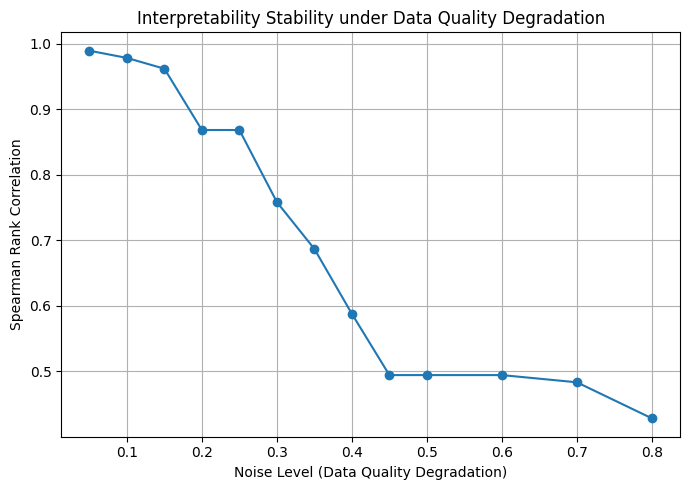

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(
    stability_df["noise_level"],
    stability_df["spearman_rank_correlation"],
    marker="o"
)

plt.xlabel("Noise Level (Data Quality Degradation)")
plt.ylabel("Spearman Rank Correlation")
plt.title("Interpretability Stability under Data Quality Degradation")
plt.grid(True)

plt.tight_layout()
plt.show()
